# TP3 — Detección de logos por template matching

![](consigna.png)

template original (400, 175) -> recortado (373, 115)


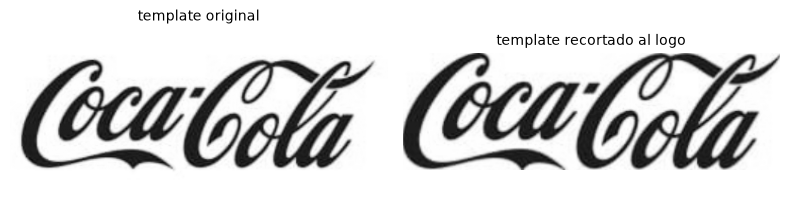

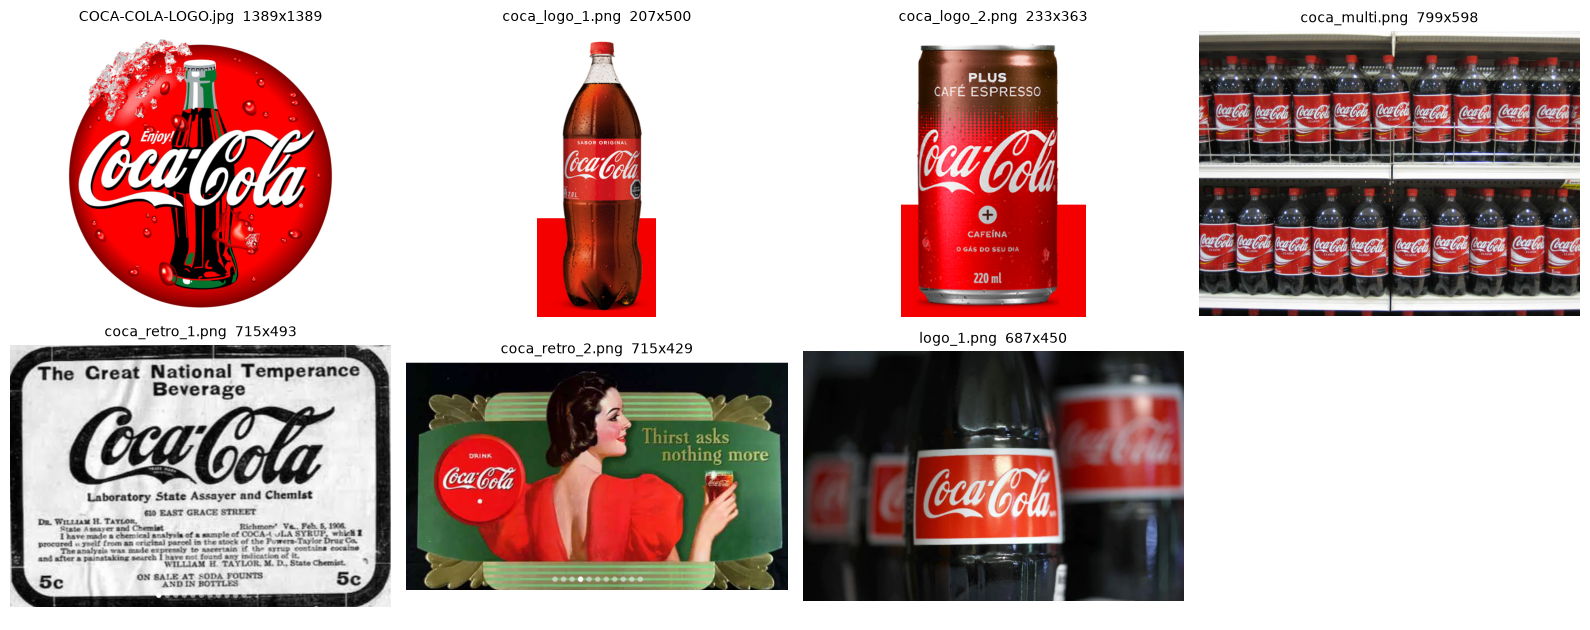

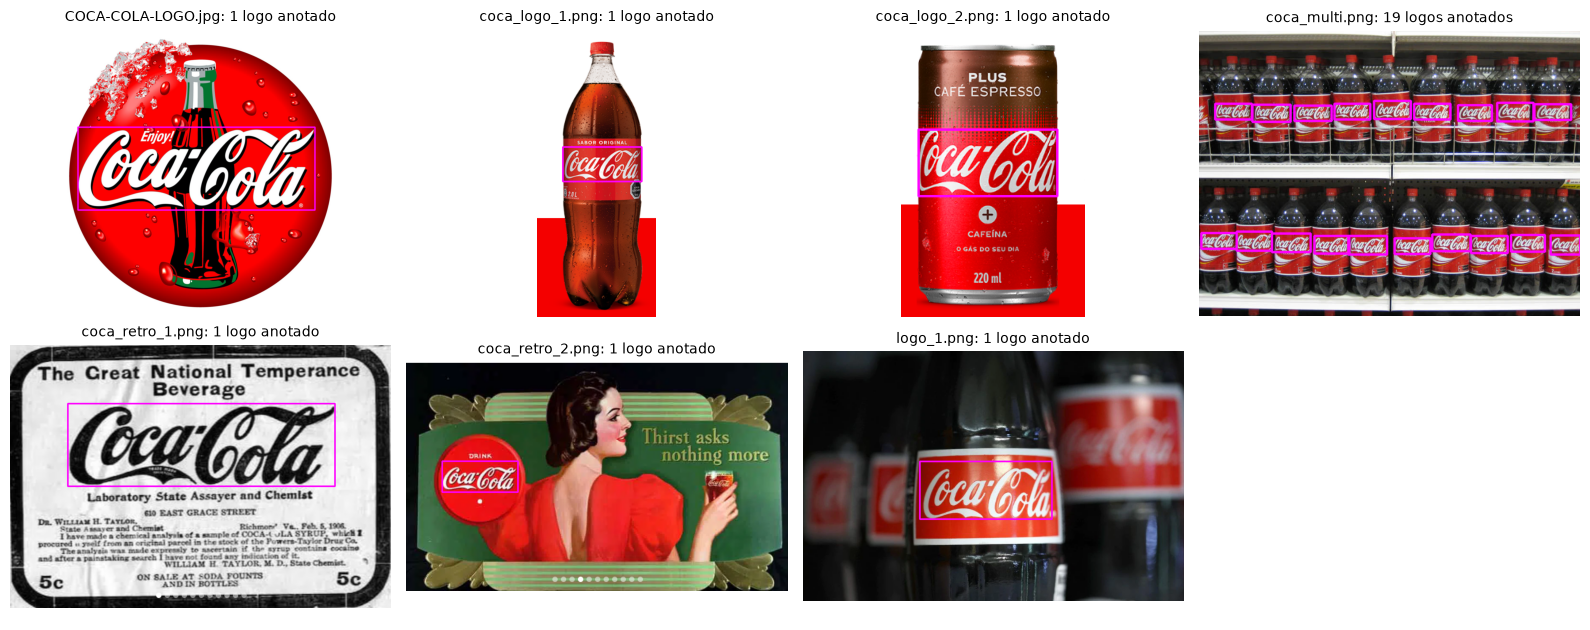

In [1]:
%matplotlib inline
import json
from pathlib import Path
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from logo_utils import Box, load_images, load_bgr, crop_to_content, intersection_area, iou, evaluate, draw_boxes, show

images = load_images("images")
grays = {name: cv.cvtColor(image, cv.COLOR_BGR2GRAY) for name, image in images.items()}
template_full = cv.cvtColor(load_bgr("template/pattern.png"), cv.COLOR_BGR2GRAY)
TEMPLATE = crop_to_content(template_full)

print(f"template original {template_full.shape[::-1]} -> recortado {TEMPLATE.shape[::-1]}")
show([template_full, TEMPLATE], ["template original", "template recortado al logo"], size=4)
show(list(images.values()), [f"{name}  {image.shape[1]}x{image.shape[0]}" for name, image in images.items()], cols=4)


def plural(count, singular, plural_form):
    return f"{count} {singular if count == 1 else plural_form}"


annotations = json.loads(Path("ground_truth.json").read_text())
GT = {name: [Box(*coords) for coords in boxes] for name, boxes in annotations.items()}
show([draw_boxes(images[name], GT[name], (255, 0, 255), labels=False) for name in images],
     [f"{name}: {plural(len(GT[name]), 'logo anotado', 'logos anotados')}" for name in images], cols=4)

## 0. Qué hay en las imágenes

Antes de buscar el logo conviene mirar en qué se diferencian las imágenes del template. Hay tres diferencias:

- **Escala.** Una vez recortado el margen blanco, el logo del template mide 373 px de ancho. En las imágenes va de unos 80 px, en cada botella de `coca_multi`, a casi 1200 px en `COCA-COLA-LOGO`. Es decir, el template va a tener que achicarse hasta un 20 % o agrandarse más de 3 veces.
- **Polaridad.** El template es rojo sobre blanco: en gris, letras oscuras sobre fondo claro. Salvo el aviso retro en blanco y negro, todas las imágenes tienen el logo blanco sobre rojo, o sea, letras claras sobre fondo oscuro. Es el mismo dibujo con los tonos invertidos.
- **Fondo y forma.** El fondo del template es blanco liso. En las imágenes, alrededor de las letras hay degradés, gotas o tramas. Además, en la lata el logo está impreso sobre un cilindro, así que se ve más angosto de lo que es.

Para poder validar los resultados con números, y no sólo a ojo, las cajas de los logos de cada imagen se marcaron a mano con `cv.selectROIs`, sin usar el detector, y se guardaron en `ground_truth.json`. Ese es el *ground truth*, que se ve en magenta en la segunda grilla de arriba. Se marcaron todos los logos que se reconocen a simple vista, incluido el de la botella de abajo a la derecha de `coca_multi`, aunque está cortado por el borde. Quedaron afuera el logo diminuto del vaso en `coca_retro_2` y los de las botellas desenfocadas de `logo_1`, porque casi no se ven.

Una detección se considera correcta si se superpone con un logo anotado con una IoU, intersección sobre unión, de al menos 0.5.

## 1. Una detección por imagen, sin falsos positivos

La herramienta base es `cv.matchTemplate` con el método `TM_CCOEFF_NORMED`, la correlación cruzada normalizada o NCC. El template se desliza sobre la imagen y en cada posición se mide cuánto se parecen el template y el pedazo de imagen que tiene debajo. A los dos se les resta su media y se los divide por su desvío. Por eso el resultado no depende del brillo ni del contraste, y queda siempre entre −1 y 1. Con una sola detección por imagen alcanza con quedarse con el máximo del mapa.

Se arranca por la versión más simple y se agrega una idea por vez, para ver qué aporta cada una. `score_maps` recorre todas las combinaciones de escala y relación de aspecto, y para cada una devuelve el mapa de NCC.

1. **Base:** el template tal cual, en gris.
2. **+ multiescala:** el template se redimensiona en 40 escalas entre 0.1 y 4, espaciadas de forma geométrica: cada una es un 10 % más grande que la anterior. Se descartan las plantillas de menos de 60 px de ancho: con tan poco detalle se parecen a cualquier textura.
3. **+ polaridad:** el logo blanco sobre rojo da una NCC *negativa*, porque es el negativo del template. Tomando el valor absoluto, el logo invertido cuenta igual que el directo. El signo se guarda para saber de cuál de los dos se trata.
4. **+ aspecto:** además de escalar, el template se estira en vertical un 15 % y un 30 %, que es lo que hace la curvatura de la lata.
5. **+ máscara:** el template es un rectángulo, pero el logo no: en las esquinas y en los huecos grandes entre letras hay fondo blanco que no forma parte del logo, y en las imágenes ese lugar lo ocupan rojo, degradés o tramas. La máscara son las letras engordadas con una dilatación de un 3 % del ancho del template. Cubre así la silueta del logo, las letras y el fondo que queda entre ellas y a su alrededor, y deja afuera alrededor de un 13 % del rectángulo, sobre todo las esquinas. `matchTemplate` compara sólo los píxeles de la máscara. No conviene una máscara más ajustada: con sólo las letras casi todos los píxeles son del mismo tono, no hay contraste que medir, y el detector deja de encontrar los logos.

In [2]:
SCALES = np.geomspace(0.1, 4, 40)
ASPECTS = (1.0, 1.15, 1.3)
MIN_WIDTH = 60


def letters_mask(template, grow=0.03):
    # Silueta del logo: letras oscuras dilatadas un 3 % del ancho, con el fondo cercano incluido.
    diameter = 2 * round(grow * template.shape[1]) + 1
    disk = cv.getStructuringElement(cv.MORPH_ELLIPSE, (diameter, diameter))
    return cv.dilate((template < 128).astype(np.uint8), disk).astype(np.float32)


def score_maps(gray, scales=SCALES, aspects=ASPECTS, polarity=True, masked=True, template=TEMPLATE):
    # Para cada escala y aspecto válidos devuelve el mapa de score, el signo de la NCC, el ancho y el alto.
    image_height, image_width = gray.shape
    image = gray.astype(np.float32)
    for scale in scales:
        for aspect in aspects:
            width = round(template.shape[1] * scale)
            height = round(template.shape[0] * scale * aspect)
            if width < MIN_WIDTH or width > image_width or height > image_height:
                continue
            interpolation = cv.INTER_AREA if scale < 1 else cv.INTER_LINEAR
            resized = cv.resize(template, (width, height), interpolation=interpolation)
            ncc = cv.matchTemplate(image, resized.astype(np.float32), cv.TM_CCOEFF_NORMED,
                                   mask=letters_mask(resized) if masked else None)
            ncc = np.nan_to_num(ncc, nan=0, posinf=0, neginf=0)  # ventanas planas dan 0/0
            yield (np.abs(ncc) if polarity else ncc), np.sign(ncc), width, height


def best_match(gray, **options):
    best = None
    for scores, signs, width, height in score_maps(gray, **options):
        _, top_score, _, (x, y) = cv.minMaxLoc(scores)
        if best is None or top_score > best.score:
            best = Box(x, y, width, height, float(top_score), int(signs[y, x]))
    return best


def is_hit(box, logos):
    return box is not None and max(iou(box, logo) for logo in logos) >= 0.5

In [3]:
variants = {
    "base": dict(scales=[1.0], aspects=(1.0,), polarity=False, masked=False),
    "+ multiescala": dict(aspects=(1.0,), polarity=False, masked=False),
    "+ polaridad": dict(aspects=(1.0,), masked=False),
    "+ aspecto": dict(masked=False),
    "+ máscara": dict(),
}
results = {variant: {name: best_match(gray, **options) for name, gray in grays.items()}
           for variant, options in variants.items()}

print(f"{'imagen':20s}" + "".join(f"{variant:>15s}" for variant in variants))
for name in images:
    row = []
    for variant in variants:
        box = results[variant][name]
        row.append("sin escala" if box is None else f"{'OK' if is_hit(box, GT[name]) else 'X':>2s} {box.score:+.2f}")
    print(f"{name:20s}" + "".join(f"{cell:>15s}" for cell in row))
print(f"{'aciertos':20s}" + "".join(f"{sum(is_hit(results[variant][name], GT[name]) for name in images):>13d}/7"
                                    for variant in variants))

imagen                         base  + multiescala    + polaridad      + aspecto      + máscara
COCA-COLA-LOGO.jpg          X +0.29        X +0.34       OK +0.47       OK +0.52       OK +0.49
coca_logo_1.png          sin escala        X +0.33       OK +0.43       OK +0.43       OK +0.51
coca_logo_2.png          sin escala        X +0.31        X +0.31        X +0.32       OK +0.31
coca_multi.png              X +0.18        X +0.32       OK +0.55       OK +0.55       OK +0.51
coca_retro_1.png           OK +0.20       OK +0.60       OK +0.60       OK +0.60       OK +0.54
coca_retro_2.png            X +0.23        X +0.33       OK +0.57       OK +0.57       OK +0.51
logo_1.png                  X +0.20        X +0.31       OK +0.40       OK +0.40       OK +0.35
aciertos                        1/7            1/7            6/7            6/7            7/7


La tabla muestra, para cada variante, si la mejor detección cae sobre un logo y con qué score.

- **Base:** sin escalar, el template de 373 px no entra en las imágenes chicas y en las demás no tiene el tamaño del logo. Sólo acierta en el aviso retro en blanco y negro, que tiene la misma polaridad que el template y un logo de 480 px, no tan lejos de 373, aunque con un score bajísimo de 0.20.
- **Multiescala:** resuelve el tamaño, pero el máximo de la NCC busca letras *oscuras* sobre fondo claro. En las imágenes con el logo invertido termina encontrando otras cosas, como el pliegue de una sombra o un texto.
- **Polaridad:** con el valor absoluto aparecen los logos blanco sobre rojo; el signo negativo de la NCC lo confirma. Ya acierta en 6 de 7.
- **Aspecto:** por sí solo no alcanza para la lata, pero hace falta para el paso siguiente.
- **Máscara:** con la máscara también se encuentra el logo de la lata, y se llega a 7 de 7. Al ignorar las esquinas del rectángulo, lo que hay alrededor del logo en la lata, la trama de puntos y el degradé, deja de penalizar la comparación. En el resto de las imágenes los scores bajan un poco, salvo en `coca_logo_1`, donde sube de 0.43 a 0.51.

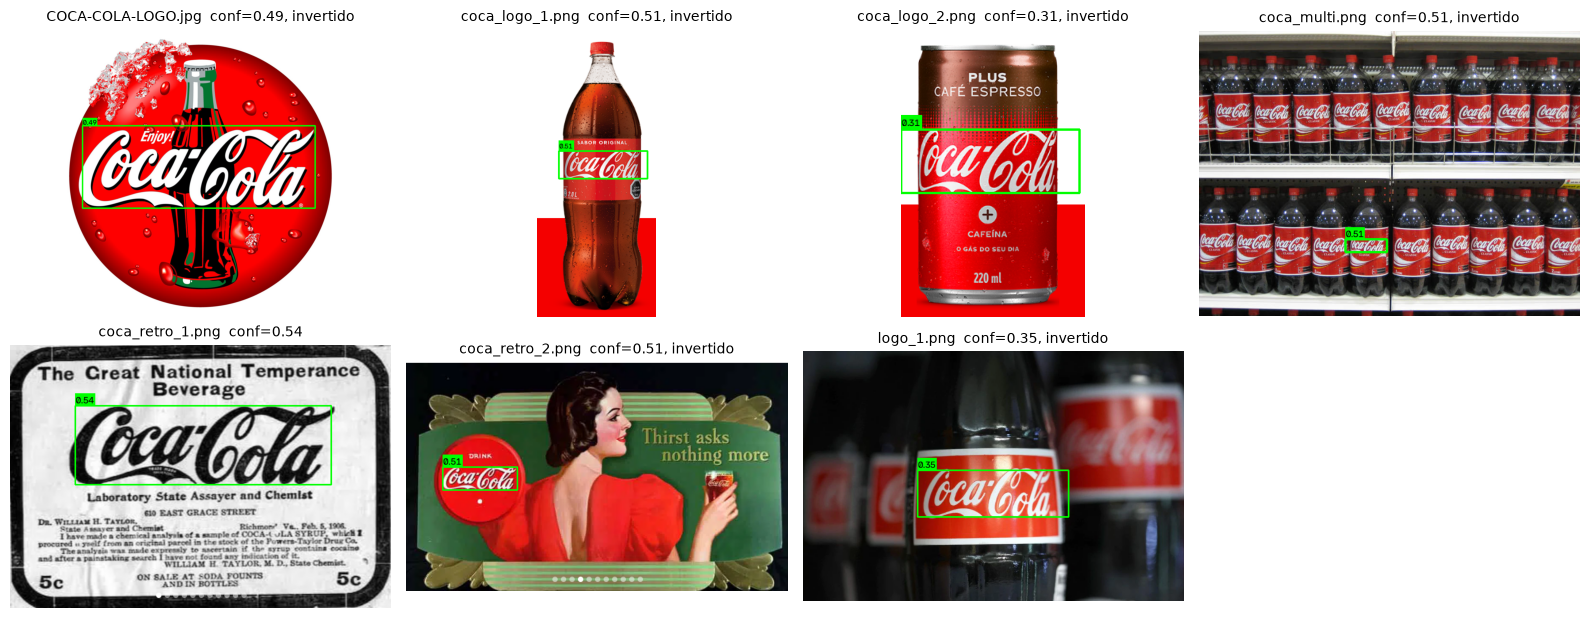

In [4]:
final = results["+ máscara"]
show([draw_boxes(images[name], [final[name]]) for name in images],
     [f"{name}  conf={final[name].score:.2f}{', invertido' if final[name].sign < 0 else ''}" for name in images], cols=4)

### Validación: ¿qué tan lejos está el falso positivo más cercano?

Que la mejor detección caiga sobre el logo no alcanza para saber si el resultado es robusto. Puede haber ganado por muy poco. Para medirlo se buscan todos los máximos locales del mapa de score, en todas las escalas, y se compara el mejor con el mejor de los que caen *fuera* del logo detectado. La diferencia entre los dos es el margen con el que el logo le gana al resto de la imagen.

La búsqueda de máximos locales, `candidates`, es la misma que se usa en los puntos 2 y 3. `overlap` mide cuánto de la caja más chica queda dentro de la otra.

In [5]:
def local_peaks(scores, width, height, floor):
    # Máximos locales en un vecindario de medio template, por encima de `floor`.
    neighborhood = np.ones((max(3, height // 2) | 1, max(3, width // 2) | 1), np.uint8)
    is_peak = (scores >= floor) & (scores == cv.dilate(scores, neighborhood))
    rows, cols = np.nonzero(is_peak)
    return zip(rows, cols)


def candidates(gray, floor=0.1, **options):
    return [Box(int(x), int(y), width, height, float(scores[y, x]), int(signs[y, x]))
            for scores, signs, width, height in score_maps(gray, **options)
            for y, x in local_peaks(scores, width, height, floor)]


def overlap(box, other):
    # Intersección sobre el área de la caja más chica: 1 si una está contenida en la otra.
    return intersection_area(box, other) / min(box.area, other.area)


all_candidates = {name: candidates(gray) for name, gray in grays.items()}

print(f"{'imagen':20s} {'logo':>6s} {'mejor fuera del logo':>21s} {'margen':>7s}")
for name, found in all_candidates.items():
    best = max(found, key=lambda box: box.score)
    rival = max((box for box in found if overlap(box, best) < 0.5 and not is_hit(box, GT[name])),
                key=lambda box: box.score)
    print(f"{name:20s} {best.score:6.2f} {rival.score:21.2f} {best.score - rival.score:7.2f}")

imagen                 logo  mejor fuera del logo  margen
COCA-COLA-LOGO.jpg     0.49                  0.23    0.27
coca_logo_1.png        0.51                  0.21    0.31
coca_logo_2.png        0.31                  0.24    0.07


coca_multi.png         0.51                  0.26    0.25
coca_retro_1.png       0.54                  0.25    0.29
coca_retro_2.png       0.51                  0.25    0.26
logo_1.png             0.35                  0.19    0.16


En las 7 imágenes la detección es correcta y no hay falsos positivos. Lo que cambia es el margen:

- En seis de las siete imágenes el logo saca entre 0.16 y 0.31 de ventaja sobre lo mejor que encuentra en el resto. Es una diferencia cómoda: el logo se distingue con claridad.
- La lata, `coca_logo_2`, es el caso más justo. El logo da 0.31 y lo siguiente queda a sólo 0.07: la deformación del cilindro hace que el template rígido nunca encaje del todo. `logo_1` también tiene un score bajo, porque la etiqueta está un poco en perspectiva y tiene reflejos.

## 2. Múltiples detecciones en `coca_multi.png`

Con varios logos ya no sirve quedarse con el máximo global. Se trabaja sobre los mismos mapas del punto 1, con el mismo template, escalas, polaridad, aspecto y máscara:

1. Se buscan los **máximos locales** de cada mapa, que son los candidatos del punto anterior.
2. Se descartan los que no superan un **umbral** de score.
3. Un mismo logo produce picos en varias escalas y posiciones vecinas, así que se aplica **supresión de no-máximos**, NMS. Se recorren los candidatos de mayor a menor score y se descarta todo el que se superpone con uno ya aceptado. La superposición se mide con `overlap` y no con la IoU: al template más chico le alcanza con encajar en una parte del logo, por ejemplo en "Cola", para dar un pico. Esa caja chica queda casi entera dentro de la grande, pero su IoU con ella es baja, así que una NMS por IoU la dejaría pasar.

El umbral se elige con datos. Se barre su valor y, para cada uno, se cuentan aciertos o TP, falsos positivos o FP y logos perdidos o FN contra los 19 logos anotados.

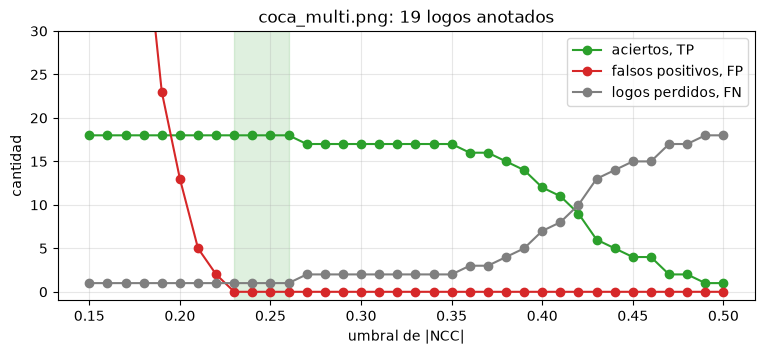

umbrales con 18 aciertos y ningún falso positivo: [0.23 0.24 0.25 0.26]


In [6]:
def nms(boxes, threshold, max_overlap=0.5):
    kept = []
    for box in sorted((box for box in boxes if box.score >= threshold), key=lambda box: -box.score):
        if all(overlap(box, previous) < max_overlap for previous in kept):
            kept.append(box)
    return kept


MULTI = "coca_multi.png"
thresholds = np.round(np.arange(0.15, 0.501, 0.01), 2)
counts = np.array([evaluate(nms(all_candidates[MULTI], threshold), GT[MULTI]) for threshold in thresholds])
hits, false_positives, misses = counts.T

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(thresholds, hits, "o-", label="aciertos, TP", color="tab:green")
ax.plot(thresholds, false_positives, "o-", label="falsos positivos, FP", color="tab:red")
ax.plot(thresholds, misses, "o-", label="logos perdidos, FN", color="tab:gray")
best_thresholds = thresholds[(false_positives == 0) & (hits == hits.max())]
ax.axvspan(best_thresholds.min(), best_thresholds.max(), color="tab:green", alpha=0.15)
ax.set(xlabel="umbral de |NCC|", ylabel="cantidad", title=f"{MULTI}: {len(GT[MULTI])} logos anotados", ylim=(-1, 30))
ax.grid(alpha=0.3)
ax.legend()
plt.show()
print(f"umbrales con {hits.max()} aciertos y ningún falso positivo:", best_thresholds)

18 detecciones -> TP=18, FP=0, FN=1, precisión=1.00, recall=0.95


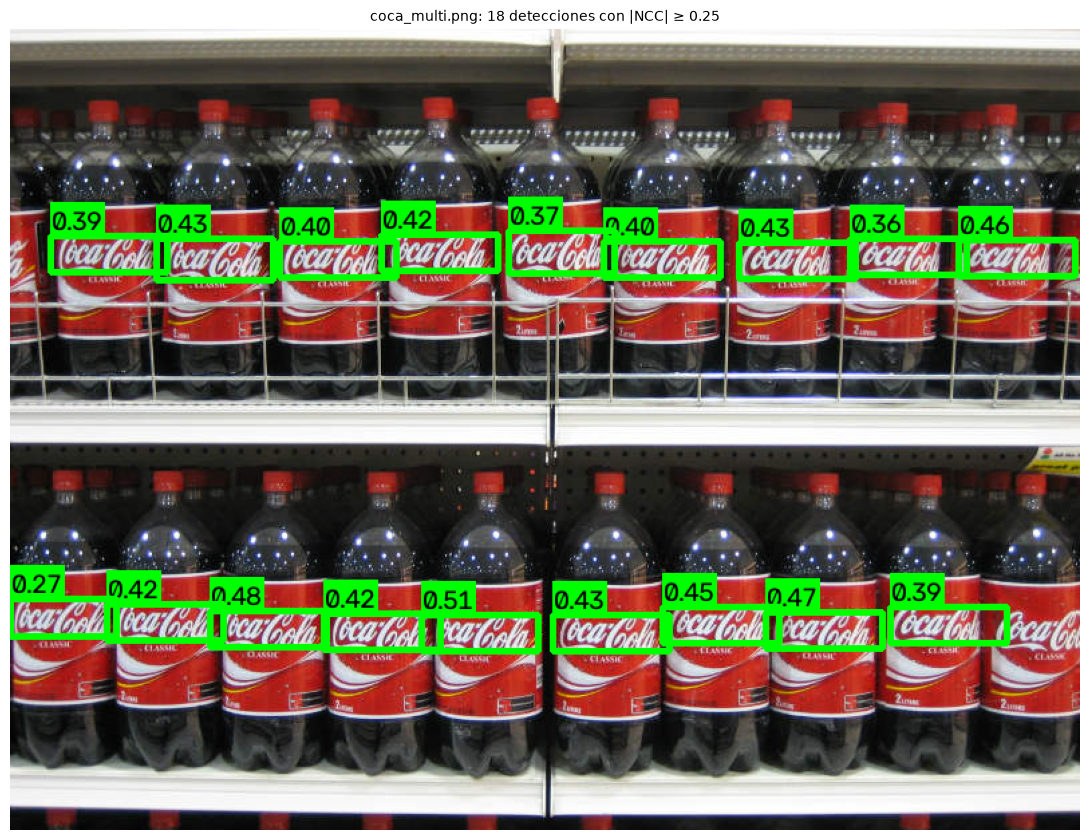

In [7]:
THRESHOLD = 0.25

detected = nms(all_candidates[MULTI], THRESHOLD)
hits, false_positives, misses = evaluate(detected, GT[MULTI])
precision = hits / (hits + false_positives)
recall = hits / (hits + misses)
print(f"{len(detected)} detecciones -> TP={hits}, FP={false_positives}, FN={misses}, "
      f"precisión={precision:.2f}, recall={recall:.2f}")
show([draw_boxes(images[MULTI], detected)], [f"{MULTI}: {len(detected)} detecciones con |NCC| ≥ {THRESHOLD}"], size=11)

### Análisis

La curva tiene tres zonas:

- **Umbral bajo**, menos de 0.23: aparecen falsos positivos, como pedazos de etiqueta, bordes de estantes o reflejos. Muy por debajo crecen a cientos, porque cualquier textura alcanza una NCC de 0.15 en alguna escala.
- **Meseta**, de 0.23 a 0.26: se encuentran 18 logos y ninguna otra cosa. El único que falta es el de la botella cortada, que no aparece con ningún umbral.
- **Umbral alto:** desde 0.27 se pierde el logo de la botella de abajo a la izquierda, que está pegado al borde de la imagen y es el de score más bajo. A partir de 0.36 empiezan a caer los del estante de arriba, que tienen más reflejos, y por encima de 0.45 quedan muy pocos.

Se toma **0.25**, dentro de la meseta. Con ese umbral el algoritmo encuentra 18 de los 19 logos, sin falsos positivos: precisión de 1 y recall de 0.95.

Todas las detecciones tienen el signo negativo, es decir, la polaridad invertida que se esperaba para el logo blanco sobre rojo. Las cajas también tienen casi todas el mismo tamaño, que es lo esperable para botellas iguales a la misma distancia de la cámara. Ninguna de las dos cosas se le impuso al algoritmo: salen solas, y eso es una buena señal de que no está acertando por casualidad.

El logo que falta es el de la botella de abajo a la derecha, al que el borde de la imagen le corta un 15 %. No es que el detector lo confunda con otra cosa: como el template entero no entra en la imagen en esa posición, `matchTemplate` ni siquiera evalúa ahí.

La meseta es angosta: entre el último falso positivo y el primer logo completo perdido hay apenas unas centésimas de score. Es lo esperable en una imagen con tanta textura, y es el principal punto débil del método.

## 3. Generalización a todas las imágenes

Se aplica exactamente el algoritmo del punto 2, con el umbral elegido en `coca_multi` y sin ningún ajuste por imagen. En verde, las detecciones con su confianza. En magenta, los logos anotados que no se detectaron.

imagen               logos  det  TP  FP  FN  IoU medio   confianzas
COCA-COLA-LOGO.jpg       1    1   1   0   0       0.94   0.49
coca_logo_1.png          1    1   1   0   0       0.73   0.51
coca_logo_2.png          1    1   1   0   0       0.75   0.31
coca_multi.png          19   18  18   0   1       0.70   0.51, 0.48, 0.47, 0.46, 0.45, 0.43 ...
coca_retro_1.png         1    1   1   0   0       0.91   0.54
coca_retro_2.png         1    1   1   0   0       0.73   0.51
logo_1.png               1    1   1   0   0       0.72   0.35
total                   25   24  24   0   1
IoU medio: superposición de cada detección con el logo anotado más cercano.


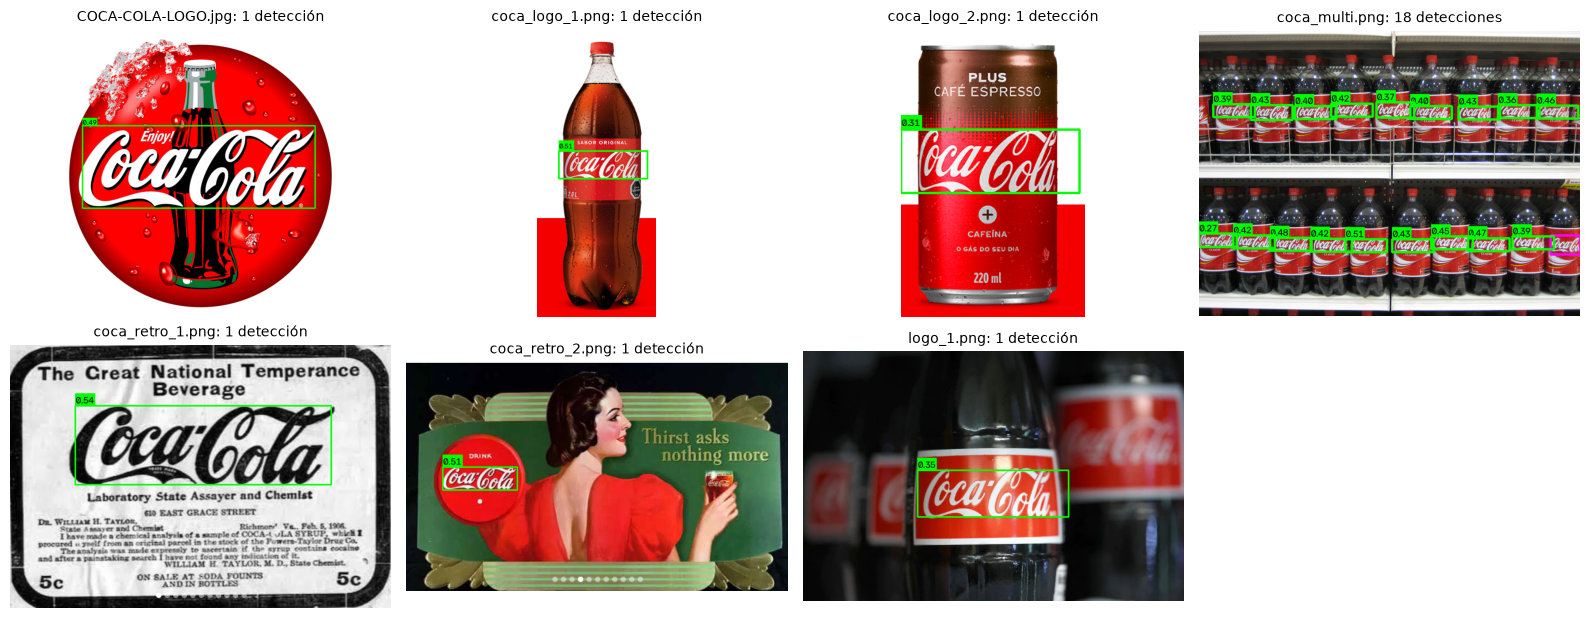

In [8]:
def detect_logos(gray, threshold=THRESHOLD):
    return nms(candidates(gray, floor=threshold), threshold)


def missed(detected, logos):
    return [logo for logo in logos if all(iou(logo, box) < 0.5 for box in detected)]


detections = {name: detect_logos(gray) for name, gray in grays.items()}

print(f"{'imagen':20s} {'logos':>5s} {'det':>4s} {'TP':>3s} {'FP':>3s} {'FN':>3s} {'IoU medio':>10s}   confianzas")
totals = np.zeros(3, int)
for name, detected in detections.items():
    counts = evaluate(detected, GT[name])
    totals += counts
    mean_iou = np.mean([max(iou(box, logo) for logo in GT[name]) for box in detected])
    confidences = ", ".join(f"{box.score:.2f}" for box in detected[:6]) + (" ..." if len(detected) > 6 else "")
    print(f"{name:20s} {len(GT[name]):5d} {len(detected):4d} {counts[0]:3d} {counts[1]:3d} {counts[2]:3d} "
          f"{mean_iou:10.2f}   {confidences}")
print(f"{'total':20s} {sum(map(len, GT.values())):5d} {sum(map(len, detections.values())):4d} "
      f"{totals[0]:3d} {totals[1]:3d} {totals[2]:3d}")
print("IoU medio: superposición de cada detección con el logo anotado más cercano.")

show([draw_boxes(draw_boxes(images[name], missed(detected, GT[name]), (255, 0, 255), labels=False), detected)
      for name, detected in detections.items()],
     [f"{name}: {plural(len(detected), 'detección', 'detecciones')}" for name, detected in detections.items()], cols=4)

### Análisis

En las siete imágenes el algoritmo encuentra 24 de los 25 logos anotados, sin ningún falso positivo; el único que falta es el cortado de `coca_multi`. En las imágenes con un solo logo da el mismo resultado que el punto 1, pero ahora sin saber de antemano cuántos logos hay: el umbral solo decide que hay uno.

Hay dos detalles que hacen falta para que esto funcione:

- **La NMS por `overlap`.** En `COCA-COLA-LOGO` y `coca_logo_1`, versiones más chicas del template encajan sobre una parte del logo, como "Cola", y dan picos de 0.26 y 0.27. Con una NMS por IoU esos picos quedarían como falsos positivos dentro de la caja buena; con `overlap` se descartan.
- **El umbral absoluto.** La lata tiene el score más bajo de todos, 0.31, y pasa el umbral sin problemas. Un umbral relativo al mejor score de cada imagen, por ejemplo el 70 % del máximo, falla justo en ese caso: como el máximo es bajo, el umbral también queda bajo y entra ruido.

Como el ground truth se marcó a mano y no con el detector, también sirve para ver qué tan bien ubicadas quedan las cajas. La IoU media va de 0.70 en `coca_multi` a más de 0.9 en las dos imágenes donde el logo es grande y nítido. En las imágenes chicas y medianas, las cajas del detector son más anchas y más bajas que las marcadas a mano: el detector siempre usa las proporciones del template, con estiramientos de a 15 %, mientras que a mano cada logo se encerró con su propia forma y un poco más de margen arriba y abajo. La diferencia más grande está en la lata, donde la caja del detector es unos 50 px más ancha: el template rígido no logra seguir al logo comprimido por el cilindro.

Los logos que se dejaron fuera del ground truth tampoco aparecen entre las detecciones, así que no cuentan como falsos positivos. Es lo esperable. El del vaso mide unos 48 px de ancho, menos que el mínimo de 60 px impuesto al template, y bajar ese mínimo no es gratis: con plantillas tan chicas el template se parece a cualquier textura. En las botellas desenfocadas, el desenfoque borra justamente los bordes finos de las letras, que es lo que mide la NCC; el mejor pico sobre la botella de la derecha es de apenas 0.15, en la zona donde en `coca_multi` aparecían decenas de falsos positivos.

## 4. Conclusiones

| punto | imágenes | logos | TP | FP | FN |
|---|---|---|---|---|---|
| 1. una detección por imagen | 7 | 7, uno por imagen | 7 | 0 | — |
| 2. múltiples en `coca_multi` | 1 | 19 | 18 | 0 | 1 |
| 3. generalización | 7 | 25 | 24 | 0 | 1 |

El template matching con NCC resolvió el TP, y cada idea que se fue agregando responde a una diferencia concreta entre el template y las imágenes. El barrido multiescala resuelve el tamaño, que en estas imágenes varía en un factor de casi 15. Tomar el valor absoluto de la NCC resuelve la polaridad invertida: es un cambio mínimo con un efecto enorme, porque sin él el algoritmo busca letras oscuras y la mayoría de estos logos son claros. La máscara con la silueta del logo hace que las esquinas del template no cuenten, y es lo que permite encontrar el logo sobre la lata. Por último, para pasar de una detección a varias alcanzó con buscar máximos locales, fijar un umbral y suprimir las cajas que se superponen.

La confianza que se muestra es el |NCC| del pico, un número entre 0 y 1 que indica cuánto se parece la forma de las letras al template. No es una probabilidad: sirve para ordenar detecciones y para fijar un umbral, pero un 0.3 en la lata y un 0.3 en la góndola no significan lo mismo.

Las limitaciones son las propias del método. El template es rígido, así que la curvatura de la lata y la perspectiva de la botella bajan el score, y tampoco tolera rotaciones, aunque en estas imágenes no hicieron falta. Necesita un tamaño mínimo para no confundirse con texturas, no puede encontrar un logo cortado por el borde porque el template no entra, y el desenfoque le quita justamente la información que usa. La meseta de umbrales sin errores es angosta, de modo que el valor elegido en `coca_multi` podría no ser el mejor para otras imágenes. Y es costoso: barre 40 escalas por 3 aspectos, y en la imagen más grande tarda varios segundos.